In [ ]:
# llm DEMO
from langchain_openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

llm = OpenAI(model='gpt-3.5-turbo-instruct')

result = llm.invoke("What is the capital of India")

print(result)

In [ ]:
# requirements.txt
# LangChain Core
langchain
langchain-core

# OpenAI Integration
langchain-openai
openai

# Anthropic Integration
langchain-anthropic

# Google Gemini (PaLM) Integration
langchain-google-genai
google-generativeai

# Hugging Face Integration
langchain-huggingface
transformers
huggingface-hub

# Environment Variable Management
python-dotenv

# Machine Learning Utilities
numpy
scikit-learn

### 2. chat models

In [ ]:
# 1_chatmodel_openai.py
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

model = ChatOpenAI(model='gpt-4', temperature=1.5, max_completion_tokens=10)

result = model.invoke("Write a 5 line poem on cricket")

print(result.content)

### 2_chatmodel_anthropic.py


In [ ]:
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv()

model = ChatAnthropic(model='claude-3-5-sonnet-20241022')

result = model.invoke('What is the capital of India')

print(result.content)

In [ ]:
# 3_chatmodel_google.py
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()

model = ChatGoogleGenerativeAI(model='gemini-1.5-pro')

result = model.invoke('What is the capital of India')

print(result.content)

In [ ]:
# 4_chatmodel_hf_api.py
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv

load_dotenv()

llm = HuggingFaceEndpoint(
    repo_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

result = model.invoke("What is the capital of India")

print(result.content)

In [ ]:
# 5_chatmodel_hf_local.py
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv

load_dotenv()

llm = HuggingFaceEndpoint(
    repo_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

result = model.invoke("What is the capital of India")

print(result.content)

In [ ]:
# 5_chatmodel_hf_local.py
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
import os

os.environ['HF_HOME'] = 'D:/huggingface_cache'

llm = HuggingFacePipeline.from_model_id(
    model_id='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
    task='text-generation',
    pipeline_kwargs=dict(
        temperature=0.5,
        max_new_tokens=100
    )
)
model = ChatHuggingFace(llm=llm)

result = model.invoke("What is the capital of India")

print(result.content)

### 3.EmbeddingModels

In [ ]:
# 3.EmbeddingModels/1_embedding_openai_query.py
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv

load_dotenv()

embedding = OpenAIEmbeddings(model='text-embedding-3-large', dimensions=32)

result = embedding.embed_query("Delhi is the capital of India")

print(str(result))

In [ ]:
# 2_embedding_openai_docs.py
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv

load_dotenv()

embedding = OpenAIEmbeddings(model='text-embedding-3-large', dimensions=32)

documents = [
    "Delhi is the capital of India",
    "Kolkata is the capital of West Bengal",
    "Paris is the capital of France"
]

result = embedding.embed_documents(documents)

print(str(result))

In [ ]:
# 3_embedding_hf_local.py
from langchain_huggingface import HuggingFaceEmbeddings

embedding = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

documents = [
    "Delhi is the capital of India",
    "Kolkata is the capital of West Bengal",
    "Paris is the capital of France"
]

vector = embedding.embed_documents(documents)

print(str(vector))

In [ ]:
# 4_document_similarity.py
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

load_dotenv()

embedding = OpenAIEmbeddings(model='text-embedding-3-large', dimensions=300)

documents = [
    "Virat Kohli is an Indian cricketer known for his aggressive batting and leadership.",
    "MS Dhoni is a former Indian captain famous for his calm demeanor and finishing skills.",
    "Sachin Tendulkar, also known as the 'God of Cricket', holds many batting records.",
    "Rohit Sharma is known for his elegant batting and record-breaking double centuries.",
    "Jasprit Bumrah is an Indian fast bowler known for his unorthodox action and yorkers."
]

query = 'tell me about bumrah'

doc_embeddings = embedding.embed_documents(documents)
query_embedding = embedding.embed_query(query)

scores = cosine_similarity([query_embedding], doc_embeddings)[0]

index, score = sorted(list(enumerate(scores)),key=lambda x:x[1])[-1]

print(query)
print(documents[index])
print("similarity score is:", score)





## Prompts in LangChain | Generative AI using LangChain |


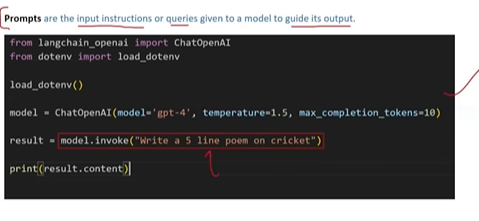
https://github.com/campusx-official/langchain-prompts 

static vs Dynamic prompt

In [ ]:
# temperature.py
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

model = ChatOpenAI(model='gpt-4', temperature=0.5)

result = model.invoke("Write a 5 line poem on cricket")

print(result.content)

In [ ]:
# temperature change
model = ChatOpenAI(model='gpt-4', temperature=1.5)

result = model.invoke("Write a 5 line poem on cricket")

print(result.content)

# same input same output need use temperature=0.0 approx
# 

# Prompt Templates

In [ ]:
# Prompt Templates
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

model = ChatOpenAI()

# detailed way
template2 = PromptTemplate(
    template='Greet this person in 5 languages. The name of the person is {name}',
    input_variables=['name']
)

# fill the values of the placeholders
prompt = template2.invoke({'name':'Shahil'})

result = model.invoke(prompt)

print(result.content)


### 2. Static Prompts vs. Dynamic Prompts

Static Prompts: Definition: The entire prompt is passed as a single, hardcoded string, or the user is asked to type the entire command themselves.

In [ ]:

from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import streamlit as st

load_dotenv()
model = ChatOpenAI()

st.header('Reasearch Tool')
user_input= st.text_input('Enter your research paper text here:')
if st.button('Summarize'):
    result =model.invoke(user_input)
    st.write(result.content)

static prompt : The Problem: Giving users complete control over the prompt leads to inconsistent outputs and high chances of hallucination.
### create prompt template to solve the problem → use dynamic prompt

In [ ]:
# template.json file

{
    "name": null,
    "input_variables": [
        "length_input",
        "paper_input",
        "style_input"
    ],
    "optional_variables": [],
    "output_parser": null,
    "partial_variables": {},
    "metadata": null,
    "tags": null,
    "template": "\nPlease summarize the research paper titled \"{paper_input}\" with the following specifications:\nExplanation Style: {style_input}  \nExplanation Length: {length_input}  \n1. Mathematical Details:  \n   - Include relevant mathematical equations if present in the paper.  \n   - Explain the mathematical concepts using simple, intuitive code snippets where applicable.  \n2. Analogies:  \n   - Use relatable analogies to simplify complex ideas.  \nIf certain information is not available in the paper, respond with: \"Insufficient information available\" instead of guessing.  \nEnsure the summary is clear, accurate, and aligned with the provided style and length.\n",
    "template_format": "f-string",
    "validate_template": true,
    "_type": "prompt"
}

In [ ]:
# instead of text input we can use select box to select research paper name and style and length of summary for better user experience more control over the output
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import streamlit as st
from langchain_core.prompts import PromptTemplate,load_prompt

load_dotenv()
model = ChatOpenAI()

st.header('Reasearch Tool')

paper_input = st.selectbox( "Select Research Paper Name", ["Attention Is All You Need", "BERT: Pre-training of Deep Bidirectional Transformers", "GPT-3: Language Models are Few-Shot Learners", "Diffusion Models Beat GANs on Image Synthesis"] )

style_input = st.selectbox( "Select Explanation Style", ["Beginner-Friendly", "Technical", "Code-Oriented", "Mathematical"] ) 

length_input = st.selectbox( "Select Explanation Length", ["Short (1-2 paragraphs)", "Medium (3-5 paragraphs)", "Long (detailed explanation)"] )

template = load_prompt('template.json')



if st.button('Summarize'):
    chain = template | model
    result = chain.invoke({
        'paper_input':paper_input,
        'style_input':style_input,
        'length_input':length_input
    })
    st.write(result.content)

In [ ]:
# prompt template with mathematical details and analogies --> it use for 
from langchain_core.prompts import PromptTemplate

# template
template = PromptTemplate(
    template="""
Please summarize the research paper titled "{paper_input}" with the following specifications:
Explanation Style: {style_input}  
Explanation Length: {length_input}  
1. Mathematical Details:  
   - Include relevant mathematical equations if present in the paper.  
   - Explain the mathematical concepts using simple, intuitive code snippets where applicable.  
2. Analogies:  
   - Use relatable analogies to simplify complex ideas.  
If certain information is not available in the paper, respond with: "Insufficient information available" instead of guessing.  
Ensure the summary is clear, accurate, and aligned with the provided style and length.
""",
input_variables=['paper_input', 'style_input','length_input'],
validate_template=True
)

template.save('template.json')

# LangChain’s PromptTemplate provides three major advantages for application development:
# 1.Built-in Validation:
# 2.Reusability
# 3.LangChain Ecosystem Integration: 

# chat_prompt_template.py



In [ ]:
from langchain_core.prompts import ChatPromptTemplate

chat_template = ChatPromptTemplate([
    ('system', 'You are a helpful {domain} expert'),
    ('human', 'Explain in simple terms, what is {topic}')
])

prompt = chat_template.invoke({'domain':'cricket','topic':'Dusra'})

print(prompt)